# Revenue Forecasting  

## Monthly Realized Revenue Forecast

This notebook estimates future **monthly total realized revenue** for the e-commerce order-line analytics project. The forecasting target is:

```text
monthly_total_realized_revenue = sum(realized_revenue) per month
```

# 1. Introduction and Business Objective

Monthly revenue forecasting helps translate historical order-line behavior into a planning view for sales, campaign timing, inventory, staffing, and logistics. The goal is not to predict each month perfectly, but to estimate likely revenue movement and provide a reasonable planning range for upcoming months.

Revenue forecasting works better when the model has more than one annual cycle to learn from. This notebook uses three business years so the monthly forecast can capture repeated seasonal patterns instead of relying on a single year of history.

# 2. Global Settings


In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
from matplotlib.ticker import FuncFormatter

# Optional stronger tabular models
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

# Visualization style
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

MODEL_DIR = Path("models")
OUTPUT_DIR = Path("outputs")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

FORECAST_HORIZON_MONTHS = 8


# 3. Data Loading


In [2]:
def load_any_data(path):
    """Load Parquet, CSV, CSV.GZ, or Excel based on file extension."""
    path = Path(path)
    suffixes = "".join(path.suffixes).lower()

    if suffixes.endswith(".parquet"):
        return pd.read_parquet(path)
    if suffixes.endswith(".csv") or suffixes.endswith(".csv.gz"):
        return pd.read_csv(path, low_memory=False)
    if suffixes.endswith(".xlsx") or suffixes.endswith(".xls"):
        return pd.read_excel(path)

    raise ValueError(f"Unsupported file type: {path}")


def load_schema_mapping():
    """Load the business-to-column schema mapping."""
    candidate_paths = [
        Path("schema_mapping.json"),
        Path("config/schema_mapping.json"),
        Path("../config/schema_mapping.json"),
    ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading schema mapping from: {path.as_posix()}")
            return json.loads(path.read_text())

    raise FileNotFoundError(
        "schema_mapping.json was not found. Place it in the notebook folder or config/."
    )


def load_orderline_data():
    """Load order-line dataset from Parquet or compressed CSV fallback."""
    candidate_paths = [
        Path("data/synthetic_orderline_2023_2024_2025_combined.parquet"),
        Path("data/synthetic_orderline_2023_2024_2025_combined.csv.gz"),
        Path("data/synthetic_orderline_2023_2024_2025_combined.csv"),
        Path("../data/synthetic_orderline_2023_2024_2025_combined.parquet"),
        Path("../data/synthetic_orderline_2023_2024_2025_combined.csv.gz"),
        Path("../data/synthetic_orderline_2023_2024_2025_combined.csv"),
    ]
    

    for path in candidate_paths:
        if path.exists():
            print(f"Loading order-line data from: {path.as_posix()}")
            return load_any_data(path)

    raise FileNotFoundError(
        "No order-line dataset found. Expected synthetic_orderline_2023_2024_2025_combined.parquet or a supported fallback."
    )


SCHEMA = load_schema_mapping()
df_raw = load_orderline_data()

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())


Loading schema mapping from: ../config/schema_mapping.json
Loading order-line data from: ../data/synthetic_orderline_2023_2024_2025_combined.parquet
Raw dataset shape: (13191756, 43)


,transaction_id,transaction_line_id,line_number,customer_key,item_key,session_key,order_timestamp,dispatch_timestamp,delivery_timestamp,return_timestamp,product_family,product_group,item_variant,size_code_public,color_group,assortment_type,customer_segment_seed,customer_region,loyalty_tier,customer_join_month,list_price,sale_price,net_revenue,realized_revenue,discount_amount,quantity,tax_rate,tax_amount,was_returned,return_reason_group,returned_quantity,returned_revenue,fulfillment_partner,delivery_mode,dispatch_delay_days,delivery_delay_days,acquisition_channel,campaign_group,traffic_source_group,order_year,order_month,order_weekday,source_year
0,TXN-2023-000000001,LINE-2023-0000000001,1,CUST-00176511,ITEM-0073714,SESS-2023-0000000001,2023-04-05 11:20:59,2023-04-06 11:20:59,2023-04-10 11:20:59,NaT,Active Lifestyle,Training Gear,premium,M,red,core_range,premium,Coastal Belt,platinum,2022-01,38.760,27.660,27.660,27.660,11.090,1,0.190,5.260,0,not_returned,0,0.000,MetroFulfill,standard,1,4,email_campaign,summer_event,type_in,2023,4,Wednesday,2023
1,TXN-2023-000000001,LINE-2023-0000000002,2,CUST-00176511,ITEM-0084605,SESS-2023-0000000001,2023-04-05 11:20:59,2023-04-06 11:20:59,2023-04-10 11:20:59,NaT,Beauty & Care,Tools,core,S,neutral,limited_run,premium,Coastal Belt,platinum,2021-06,14.670,10.410,31.220,31.220,12.780,3,0.070,2.190,0,not_returned,0,0.000,MetroFulfill,standard,1,4,email_campaign,summer_event,partner_site,2023,4,Wednesday,2023
2,TXN-2023-000000001,LINE-2023-0000000003,3,CUST-00176511,ITEM-0065742,SESS-2023-0000000001,2023-04-05 11:20:59,2023-04-06 11:20:59,2023-04-10 11:20:59,NaT,Outdoor Living,Weather Gear,seasonal,XL,green,core_range,premium,Southridge,platinum,2023-09,38.990,27.410,27.410,27.410,11.580,1,0.190,5.210,0,not_returned,0,0.000,MetroFulfill,standard,1,4,email_campaign,summer_event,social_feed,2023,4,Wednesday,2023
3,TXN-2023-000000001,LINE-2023-0000000004,4,CUST-00176511,ITEM-0096909,SESS-2023-0000000001,2023-04-05 11:20:59,2023-04-06 11:20:59,2023-04-10 11:20:59,NaT,Everyday Apparel,Footwear,core,L,warm,clearance,premium,Highland,platinum,2023-09,37.600,26.890,26.890,26.890,10.710,1,0.000,0.000,0,not_returned,0,0.000,MetroFulfill,standard,1,4,email_campaign,summer_event,partner_site,2023,4,Wednesday,2023
4,TXN-2023-000000001,LINE-2023-0000000005,5,CUST-00176511,ITEM-0002461,SESS-2023-0000000001,2023-04-05 11:20:59,2023-04-06 11:20:59,2023-04-10 11:20:59,NaT,Home Comfort,Textiles,core,OneSize,cool,core_range,premium,Eastvale,platinum,2020-01,29.950,20.810,20.810,20.810,9.140,1,0.190,3.950,0,not_returned,0,0.000,MetroFulfill,standard,1,4,email_campaign,summer_event,retargeting,2023,4,Wednesday,2023


# 4. Data Validation and Date Preparation

The first checks confirm that the fields needed for forecasting are available and usable.

The preparation focuses on:

- order date
- realized revenue
- net revenue
- return flag
- quantity and price fields
- dispatch and delivery timing

The forecasting target is based on `realized_revenue`, because it reflects revenue retained after returns.

In [3]:
def prepare_analysis_data(df, schema):
    """Prepare order-line data for monthly revenue forecasting."""
    out = df.copy()

    date_col = schema["order_date"]
    realized_col = schema["realized_revenue"]
    net_col = schema["original_revenue"]
    return_col = schema["return_flag"]

    if date_col not in out.columns:
        raise ValueError(f"Required date column missing: {date_col}")
    if realized_col not in out.columns:
        raise ValueError(f"Required realized revenue column missing: {realized_col}")

    # Convert dates
    for col in [schema.get("order_date"), schema.get("dispatch_date"), schema.get("delivery_date"), schema.get("return_date")]:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")

    out = out.dropna(subset=[date_col]).copy()

    # Numeric conversion
    numeric_cols = [
        realized_col,
        net_col,
        schema.get("quantity"),
        schema.get("price"),
        schema.get("list_price"),
        schema.get("discount"),
        schema.get("tax_rate"),
        schema.get("tax_amount"),
        schema.get("dispatch_delay"),
        schema.get("shipping_delay"),
    ]

    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Return flag
    if return_col in out.columns:
        out[return_col] = pd.to_numeric(out[return_col], errors="coerce").fillna(0).astype(int)
    else:
        out[return_col] = 0

    # Remove rows with missing target
    out = out.dropna(subset=[realized_col]).copy()

    # Guardrails
    out = out[out[realized_col] >= 0].copy()

    return out


analysis_df = prepare_analysis_data(df_raw, SCHEMA)

date_col = SCHEMA["order_date"]
realized_col = SCHEMA["realized_revenue"]
net_col = SCHEMA["original_revenue"]
return_col = SCHEMA["return_flag"]

print("Prepared dataset shape:", analysis_df.shape)
print("Date range:", analysis_df[date_col].min(), "to", analysis_df[date_col].max())
print("Total realized revenue:", analysis_df[realized_col].sum())
print("Return rate:", analysis_df[return_col].mean())


Prepared dataset shape: (13191756, 43)
Date range: 2023-01-01 00:01:26 to 2025-12-31 23:58:39
Total realized revenue: 442967366.07
Return rate: 0.11032958766065716


# 5. Monthly Revenue Aggregation

The order-line data is aggregated into one row per month. The target is:

```text
total_realized_revenue = sum(realized_revenue)
```


In [4]:
def build_monthly_revenue_table(df, schema):
    """Aggregate order-line data to one row per month."""
    data = df.copy()

    date_col = schema["order_date"]
    realized_col = schema["realized_revenue"]
    net_col = schema["original_revenue"]

    data["month"] = data[date_col].dt.to_period("M").dt.to_timestamp()

    aggregation = {
        "total_realized_revenue": (realized_col, "sum"),
        "total_net_revenue": (net_col, "sum"),
        "order_lines": (schema["order_line_id"], "count"),
        "unique_transactions": (schema["order_id"], "nunique"),
        "unique_customers": (schema["customer_id"], "nunique"),
        "unique_items": (schema["item_id"], "nunique"),
        "return_rate": (schema["return_flag"], "mean"),
        "avg_order_line_revenue": (realized_col, "mean"),
        "total_quantity": (schema["quantity"], "sum"),
    }

    if schema.get("price") in data.columns:
        aggregation["avg_price"] = (schema["price"], "mean")
    if schema.get("discount") in data.columns:
        aggregation["avg_discount"] = (schema["discount"], "mean")
    if schema.get("dispatch_delay") in data.columns:
        aggregation["avg_dispatch_delay"] = (schema["dispatch_delay"], "mean")
    if schema.get("shipping_delay") in data.columns:
        aggregation["avg_delivery_delay"] = (schema["shipping_delay"], "mean")

    monthly = data.groupby("month").agg(**aggregation).reset_index()

    full_month_index = pd.date_range(
        start=monthly["month"].min(),
        end=monthly["month"].max(),
        freq="MS"
    )

    monthly = (
        monthly.set_index("month")
        .reindex(full_month_index)
        .rename_axis("month")
        .reset_index()
    )

    # Fill missing months with zero activity and safe averages.
    count_like_cols = [
        "total_realized_revenue", "total_net_revenue", "order_lines",
        "unique_transactions", "unique_customers", "unique_items", "total_quantity"
    ]
    for col in count_like_cols:
        if col in monthly.columns:
            monthly[col] = monthly[col].fillna(0)

    avg_like_cols = [
        "return_rate", "avg_order_line_revenue", "avg_price", "avg_discount",
        "avg_dispatch_delay", "avg_delivery_delay"
    ]
    for col in avg_like_cols:
        if col in monthly.columns:
            monthly[col] = monthly[col].fillna(0)

    return monthly


monthly_df = build_monthly_revenue_table(analysis_df, SCHEMA)

print("Monthly table shape:", monthly_df.shape)
display(monthly_df)


Monthly table shape: (36, 14)


,month,total_realized_revenue,total_net_revenue,order_lines,unique_transactions,unique_customers,unique_items,return_rate,avg_order_line_revenue,total_quantity,avg_price,avg_discount,avg_dispatch_delay,avg_delivery_delay
0,2023-01-01,"10,187,991.330","11,321,914.220",287942,152284,116092,122820,0.121,35.382,433339,27.499,7.777,1.110,4.154
1,2023-02-01,"9,528,086.170","10,346,032.860",261489,138298,107649,116497,0.093,36.438,394443,27.631,7.488,1.101,4.158
2,2023-03-01,"10,307,416.400","11,243,264.050",303204,160423,120826,126015,0.100,33.995,457614,25.897,9.968,1.101,4.159
3,2023-04-01,"11,349,019.720","12,300,870.290",316317,167379,124587,128647,0.091,35.879,476805,27.172,8.146,1.100,4.157
4,2023-05-01,"11,961,772.940","13,069,942.660",336135,177435,130256,132378,0.101,35.586,508257,27.097,8.328,1.100,4.163
5,2023-06-01,"10,776,933.800","11,840,736.470",321114,169565,126023,129278,0.109,33.561,484716,25.756,10.304,1.105,4.155
6,2023-07-01,"11,083,895.220","12,066,260.820",308540,163101,122051,126759,0.096,35.924,465883,27.258,7.953,1.101,4.155
7,2023-08-01,"11,695,963.520","12,833,292.750",347104,183361,133667,134014,0.106,33.696,523252,25.842,10.161,1.100,4.157
8,2023-09-01,"12,884,132.920","14,181,701.330",367788,194620,139369,137753,0.110,35.031,554073,26.954,8.491,1.101,4.159
9,2023-10-01,"13,117,122.080","14,489,392.160",393544,208329,146493,141685,0.115,33.331,593528,25.716,10.259,1.100,4.152


The monthly table is the forecasting base. It keeps the target revenue series and adds context such as order volume, customer count, return rate, and delivery timing. This matters because monthly revenue rarely moves for one reason only. Volume, returns, channel mix, and product mix can all affect the final realized revenue pattern.

## Optional channel and product-family share features

When channel and product-family fields are available, the notebook adds monthly share features. These features capture whether changes in business mix are associated with changes in monthly revenue.

In [5]:
def add_share_features(monthly_df, order_df, schema, category_col, prefix, top_n=5):
    """Add monthly realized-revenue share and order-line share features for top categories."""
    if category_col not in order_df.columns:
        return monthly_df

    data = order_df.copy()
    data["month"] = data[schema["order_date"]].dt.to_period("M").dt.to_timestamp()

    top_categories = (
        data.groupby(category_col)[schema["realized_revenue"]]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    if len(top_categories) == 0:
        return monthly_df

    subset = data[data[category_col].isin(top_categories)].copy()

    revenue_pivot = subset.pivot_table(
        index="month",
        columns=category_col,
        values=schema["realized_revenue"],
        aggfunc="sum",
        fill_value=0
    )

    lines_pivot = subset.pivot_table(
        index="month",
        columns=category_col,
        values=schema["order_line_id"],
        aggfunc="count",
        fill_value=0
    )

    total_revenue = data.groupby("month")[schema["realized_revenue"]].sum()
    total_lines = data.groupby("month")[schema["order_line_id"]].count()

    revenue_share = revenue_pivot.div(total_revenue, axis=0).fillna(0)
    line_share = lines_pivot.div(total_lines, axis=0).fillna(0)

    revenue_share.columns = [
        f"{prefix}_revenue_share_{str(col).replace(' ', '_').replace('/', '_')[:40]}"
        for col in revenue_share.columns
    ]
    line_share.columns = [
        f"{prefix}_line_share_{str(col).replace(' ', '_').replace('/', '_')[:40]}"
        for col in line_share.columns
    ]

    share = pd.concat([revenue_share, line_share], axis=1).reset_index()
    out = monthly_df.merge(share, on="month", how="left")

    share_cols = [c for c in out.columns if c.startswith(f"{prefix}_")]
    out[share_cols] = out[share_cols].fillna(0)

    return out


monthly_df = add_share_features(monthly_df, analysis_df, SCHEMA, SCHEMA["channel"], "channel", top_n=5)
monthly_df = add_share_features(monthly_df, analysis_df, SCHEMA, SCHEMA["product_category"], "product_family", top_n=5)

print("Monthly table with share features:", monthly_df.shape)
display(monthly_df.head())


Monthly table with share features: (36, 34)


,month,total_realized_revenue,total_net_revenue,order_lines,unique_transactions,unique_customers,unique_items,return_rate,avg_order_line_revenue,total_quantity,avg_price,avg_discount,avg_dispatch_delay,avg_delivery_delay,channel_revenue_share_direct_web,channel_revenue_share_email_campaign,channel_revenue_share_organic_search,channel_revenue_share_paid_search,channel_revenue_share_social_media,channel_line_share_direct_web,channel_line_share_email_campaign,channel_line_share_organic_search,channel_line_share_paid_search,channel_line_share_social_media,product_family_revenue_share_Active_Lifestyle,product_family_revenue_share_Digital_Accessories,product_family_revenue_share_Everyday_Apparel,product_family_revenue_share_Home_Comfort,product_family_revenue_share_Outdoor_Living,product_family_line_share_Active_Lifestyle,product_family_line_share_Digital_Accessories,product_family_line_share_Everyday_Apparel,product_family_line_share_Home_Comfort,product_family_line_share_Outdoor_Living
0,2023-01-01,"10,187,991.330","11,321,914.220",287942,152284,116092,122820,0.121,35.382,433339,27.499,7.777,1.110,4.154,0.266,0.119,0.185,0.129,0.104,0.259,0.120,0.182,0.130,0.108,0.119,0.103,0.156,0.167,0.125,0.101,0.105,0.168,0.123,0.079
1,2023-02-01,"9,528,086.170","10,346,032.860",261489,138298,107649,116497,0.093,36.438,394443,27.631,7.488,1.101,4.158,0.268,0.119,0.185,0.127,0.106,0.259,0.120,0.182,0.130,0.110,0.118,0.104,0.158,0.165,0.127,0.100,0.106,0.168,0.121,0.079
2,2023-03-01,"10,307,416.400","11,243,264.050",303204,160423,120826,126015,0.100,33.995,457614,25.897,9.968,1.101,4.159,0.240,0.128,0.184,0.166,0.126,0.231,0.129,0.181,0.168,0.131,0.121,0.103,0.156,0.167,0.124,0.101,0.105,0.167,0.122,0.078
3,2023-04-01,"11,349,019.720","12,300,870.290",316317,167379,124587,128647,0.091,35.879,476805,27.172,8.146,1.100,4.157,0.249,0.119,0.181,0.149,0.118,0.241,0.119,0.180,0.149,0.122,0.119,0.103,0.157,0.167,0.126,0.100,0.105,0.168,0.123,0.078
4,2023-05-01,"11,961,772.940","13,069,942.660",336135,177435,130256,132378,0.101,35.586,508257,27.097,8.328,1.100,4.163,0.248,0.120,0.183,0.146,0.115,0.240,0.120,0.181,0.148,0.119,0.120,0.104,0.156,0.165,0.127,0.101,0.106,0.167,0.122,0.079


Share features add a compact view of business mix. If a higher share of revenue comes from certain channels or product families in a given month, the model can use that context when estimating future revenue.

# 6. Exploratory Revenue Trend Analysis

Before modeling, we first look at the monthly revenue trend. This helps us see the repeated seasonal pattern, how much revenue changes from month to month, and any unusual high or low months that could make the forecast less reliable.

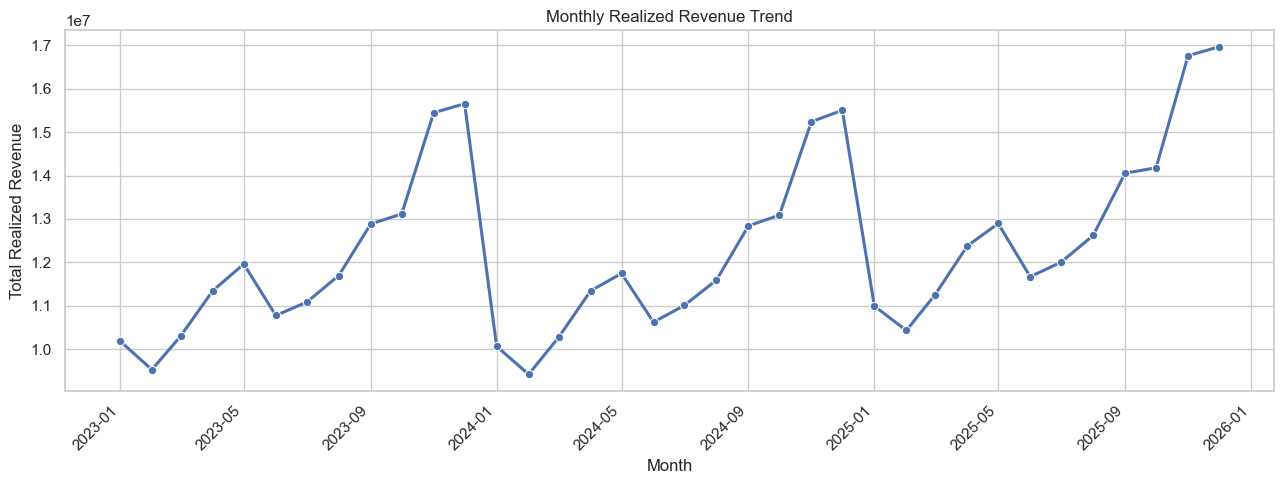

,month,total_realized_revenue,total_net_revenue,unique_transactions,unique_customers,return_rate
0,2023-01-01,"10,187,991.330","11,321,914.220",152284,116092,0.121
1,2023-02-01,"9,528,086.170","10,346,032.860",138298,107649,0.093
2,2023-03-01,"10,307,416.400","11,243,264.050",160423,120826,0.100
3,2023-04-01,"11,349,019.720","12,300,870.290",167379,124587,0.091
4,2023-05-01,"11,961,772.940","13,069,942.660",177435,130256,0.101
5,2023-06-01,"10,776,933.800","11,840,736.470",169565,126023,0.109
6,2023-07-01,"11,083,895.220","12,066,260.820",163101,122051,0.096
7,2023-08-01,"11,695,963.520","12,833,292.750",183361,133667,0.106
8,2023-09-01,"12,884,132.920","14,181,701.330",194620,139369,0.110
9,2023-10-01,"13,117,122.080","14,489,392.160",208329,146493,0.115


In [6]:
plt.figure(figsize=(13, 5))
sns.lineplot(data=monthly_df, x="month", y="total_realized_revenue", marker="o", linewidth=2.2)
plt.title("Monthly Realized Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Realized Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(monthly_df[[
    "month", "total_realized_revenue", "total_net_revenue",
    "unique_transactions", "unique_customers", "return_rate"
]])


**Interpretation:** The historical line shows the pattern the models need to learn. Revenue is not flat across the year, so seasonality and recent momentum should be part of the forecasting setup. The repeated annual coverage makes the monthly forecast more credible than a short single-cycle history, but uncertainty remains higher around sharp seasonal changes.

# 7. Forecasting Feature Engineering

Forecasting features must avoid future leakage.

The notebook creates:

- calendar features
- revenue lag features
- rolling features based only on previous months
- shifted business indicator features
- shifted channel and product-family mix features


In [7]:
def add_forecasting_features(monthly):
    """Create leakage-safe forecasting features from monthly revenue data."""
    df = monthly.sort_values("month").copy()

    df["target_eur"] = df["total_realized_revenue"]
    df["target_log"] = np.log1p(df["target_eur"].clip(lower=0))

    # Calendar features
    df["year"] = df["month"].dt.year
    df["month_num"] = df["month"].dt.month
    df["quarter"] = df["month"].dt.quarter
    df["month_index"] = np.arange(len(df))
    df["is_year_start"] = (df["month_num"] == 1).astype(int)
    df["is_year_end"] = (df["month_num"] == 12).astype(int)

    # Revenue lag features
    for lag in [1, 2, 3, 6, 12]:
        if len(df) > lag:
            df[f"revenue_lag_{lag}"] = df["target_eur"].shift(lag)

    # Rolling revenue features based only on previous months
    shifted_revenue = df["target_eur"].shift(1)
    df["revenue_rolling_mean_3"] = shifted_revenue.rolling(window=3, min_periods=1).mean()
    df["revenue_rolling_mean_6"] = shifted_revenue.rolling(window=6, min_periods=1).mean()
    df["revenue_rolling_std_3"] = shifted_revenue.rolling(window=3, min_periods=2).std()
    df["revenue_rolling_std_6"] = shifted_revenue.rolling(window=6, min_periods=2).std()

    # Business indicators shifted to avoid leakage
    business_cols = [
        "order_lines", "unique_transactions", "unique_customers", "unique_items",
        "return_rate", "avg_order_line_revenue", "avg_price", "avg_discount",
        "total_quantity", "avg_dispatch_delay", "avg_delivery_delay"
    ]
    business_cols += [
        c for c in df.columns
        if c.startswith("channel_") or c.startswith("product_family_")
    ]
    business_cols = [c for c in business_cols if c in df.columns]

    for col in business_cols:
        df[f"{col}_lag_1"] = df[col].shift(1)
        df[f"{col}_rolling_mean_3"] = df[col].shift(1).rolling(window=3, min_periods=1).mean()

        if len(df) > 12:
            df[f"{col}_same_month_last_year"] = df[col].shift(12)

    return df


feature_df = add_forecasting_features(monthly_df)

print("Feature table shape:", feature_df.shape)
display(feature_df.head())


Feature table shape: (36, 144)


,month,total_realized_revenue,total_net_revenue,order_lines,unique_transactions,unique_customers,unique_items,return_rate,avg_order_line_revenue,total_quantity,avg_price,avg_discount,avg_dispatch_delay,avg_delivery_delay,channel_revenue_share_direct_web,channel_revenue_share_email_campaign,channel_revenue_share_organic_search,channel_revenue_share_paid_search,channel_revenue_share_social_media,channel_line_share_direct_web,channel_line_share_email_campaign,channel_line_share_organic_search,channel_line_share_paid_search,channel_line_share_social_media,product_family_revenue_share_Active_Lifestyle,product_family_revenue_share_Digital_Accessories,product_family_revenue_share_Everyday_Apparel,product_family_revenue_share_Home_Comfort,product_family_revenue_share_Outdoor_Living,product_family_line_share_Active_Lifestyle,product_family_line_share_Digital_Accessories,product_family_line_share_Everyday_Apparel,product_family_line_share_Home_Comfort,product_family_line_share_Outdoor_Living,target_eur,target_log,year,month_num,quarter,month_index,is_year_start,is_year_end,revenue_lag_1,revenue_lag_2,revenue_lag_3,revenue_lag_6,revenue_lag_12,revenue_rolling_mean_3,revenue_rolling_mean_6,revenue_rolling_std_3,revenue_rolling_std_6,order_lines_lag_1,order_lines_rolling_mean_3,order_lines_same_month_last_year,unique_transactions_lag_1,unique_transactions_rolling_mean_3,unique_transactions_same_month_last_year,unique_customers_lag_1,unique_customers_rolling_mean_3,unique_customers_same_month_last_year,unique_items_lag_1,unique_items_rolling_mean_3,unique_items_same_month_last_year,return_rate_lag_1,return_rate_rolling_mean_3,return_rate_same_month_last_year,avg_order_line_revenue_lag_1,avg_order_line_revenue_rolling_mean_3,avg_order_line_revenue_same_month_last_year,avg_price_lag_1,avg_price_rolling_mean_3,avg_price_same_month_last_year,avg_discount_lag_1,avg_discount_rolling_mean_3,avg_discount_same_month_last_year,total_quantity_lag_1,total_quantity_rolling_mean_3,total_quantity_same_month_last_year,avg_dispatch_delay_lag_1,avg_dispatch_delay_rolling_mean_3,avg_dispatch_delay_same_month_last_year,avg_delivery_delay_lag_1,avg_delivery_delay_rolling_mean_3,avg_delivery_delay_same_month_last_year,channel_revenue_share_direct_web_lag_1,channel_revenue_share_direct_web_rolling_mean_3,channel_revenue_share_direct_web_same_month_last_year,channel_revenue_share_email_campaign_lag_1,channel_revenue_share_email_campaign_rolling_mean_3,channel_revenue_share_email_campaign_same_month_last_year,channel_revenue_share_organic_search_lag_1,channel_revenue_share_organic_search_rolling_mean_3,channel_revenue_share_organic_search_same_month_last_year,channel_revenue_share_paid_search_lag_1,channel_revenue_share_paid_search_rolling_mean_3,channel_revenue_share_paid_search_same_month_last_year,channel_revenue_share_social_media_lag_1,channel_revenue_share_social_media_rolling_mean_3,channel_revenue_share_social_media_same_month_last_year,channel_line_share_direct_web_lag_1,channel_line_share_direct_web_rolling_mean_3,channel_line_share_direct_web_same_month_last_year,channel_line_share_email_campaign_lag_1,channel_line_share_email_campaign_rolling_mean_3,channel_line_share_email_campaign_same_month_last_year,channel_line_share_organic_search_lag_1,channel_line_share_organic_search_rolling_mean_3,channel_line_share_organic_search_same_month_last_year,channel_line_share_paid_search_lag_1,channel_line_share_paid_search_rolling_mean_3,channel_line_share_paid_search_same_month_last_year,channel_line_share_social_media_lag_1,channel_line_share_social_media_rolling_mean_3,channel_line_share_social_media_same_month_last_year,product_family_revenue_share_Active_Lifestyle_lag_1,product_family_revenue_share_Active_Lifestyle_rolling_mean_3,product_family_revenue_share_Active_Lifestyle_same_month_last_year,product_family_revenue_share_Digital_Accessories_lag_1,product_family_revenue_share_Digital_Accessories_rolling_mean_3,product_family_revenue_share_Digital_Accessories

## Final modeling table

The first months in the series do not have enough lag history, so those rows are removed for modeling. Remaining missing values are handled inside the model pipelines. This keeps the feature table reproducible without manually filling every column.

In [8]:
exclude_cols = [
    "month", "target_eur", "target_log", "total_realized_revenue", "total_net_revenue"
]

raw_current_cols = [
    "order_lines", "unique_transactions", "unique_customers", "unique_items",
    "return_rate", "avg_order_line_revenue", "avg_price", "avg_discount",
    "total_quantity", "avg_dispatch_delay", "avg_delivery_delay"
]

feature_cols = [
    c for c in feature_df.columns
    if c not in exclude_cols
    and c not in raw_current_cols
    and not (c.startswith("channel_") and not ("_lag_" in c or "_rolling_" in c or "_same_month" in c))
    and not (c.startswith("product_family_") and not ("_lag_" in c or "_rolling_" in c or "_same_month" in c))
]

model_df = feature_df.dropna(subset=["revenue_lag_1"]).copy()

std_cols = [c for c in model_df.columns if "rolling_std" in c]
model_df[std_cols] = model_df[std_cols].fillna(0)

print("Modeling table shape:", model_df.shape)
print("Number of features:", len(feature_cols))
display(model_df[["month", "target_eur", "target_log"] + feature_cols[:8]].head())


Modeling table shape: (35, 144)
Number of features: 108


,month,target_eur,target_log,year,month_num,quarter,month_index,is_year_start,is_year_end,revenue_lag_1,revenue_lag_2
1,2023-02-01,"9,528,086.170",16.070,2023,2,1,1,0,0,"10,187,991.330",NaN
2,2023-03-01,"10,307,416.400",16.148,2023,3,1,2,0,0,"9,528,086.170","10,187,991.330"
3,2023-04-01,"11,349,019.720",16.245,2023,4,2,3,0,0,"10,307,416.400","9,528,086.170"
4,2023-05-01,"11,961,772.940",16.297,2023,5,2,4,0,0,"11,349,019.720","10,307,416.400"
5,2023-06-01,"10,776,933.800",16.193,2023,6,2,5,0,0,"11,961,772.940","11,349,019.720"


After lag creation, the modeling table keeps 35 monthly observations. That is enough for a practical forecasting exercise, but still small enough that validation needs to be conservative. For that reason, I use a time-based holdout and keeps simple baselines in the comparison.

# 8. Train/Test Time-Based Split

Forecasting is evaluated with a time-based split. Older months are used for training, and the latest months are held out for testing. This mirrors the real forecasting situation more closely than a random split, where future patterns could leak into training.

In [9]:
def time_based_monthly_split(df, test_fraction=0.2, min_test_months=3):
    """Split monthly data chronologically into train and test sets."""
    df = df.sort_values("month").copy()

    if len(df) < 8:
        raise ValueError(
            "Not enough model-ready monthly observations for a reliable forecasting split. "
            "At least 8 months are recommended."
        )

    test_size = max(min_test_months, int(len(df) * test_fraction))
    test_size = min(test_size, max(1, len(df) - 6))

    train = df.iloc[:-test_size].copy()
    test = df.iloc[-test_size:].copy()

    return train, test, test_size


train_df, test_df, test_size_months = time_based_monthly_split(model_df)

print("Train months:", train_df["month"].min().date(), "to", train_df["month"].max().date())
print("Test months:", test_df["month"].min().date(), "to", test_df["month"].max().date())
print("Test size months:", test_size_months)


Train months: 2023-02-01 to 2025-05-01
Test months: 2025-06-01 to 2025-12-01
Test size months: 7


The split holds out the latest seven months for testing. 

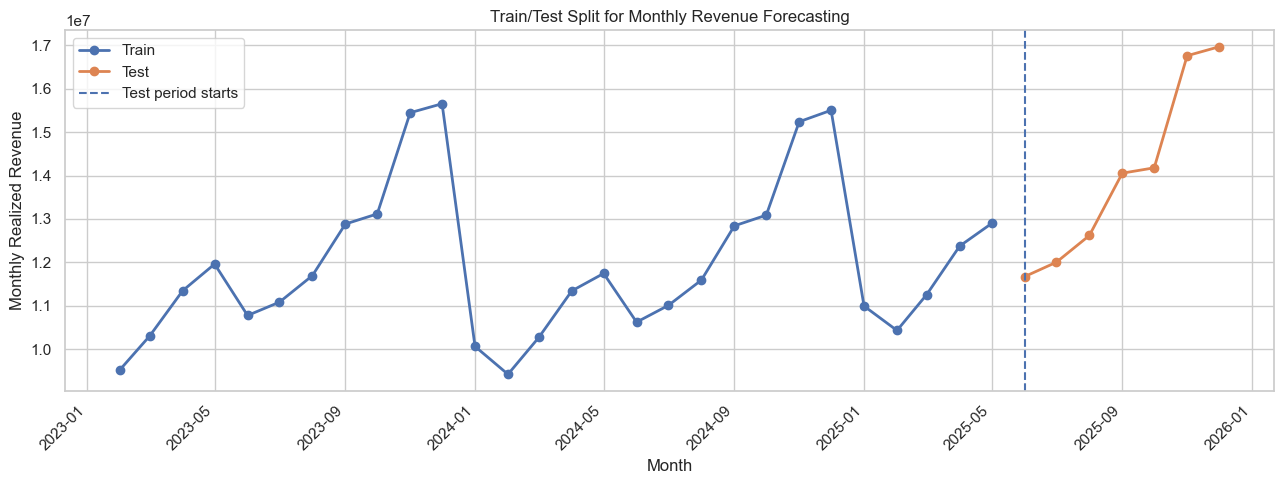

In [10]:
plt.figure(figsize=(13, 5))
plt.plot(train_df["month"], train_df["target_eur"], marker="o", label="Train", linewidth=2)
plt.plot(test_df["month"], test_df["target_eur"], marker="o", label="Test", linewidth=2)
plt.axvline(test_df["month"].min(), linestyle="--", linewidth=1.5, label="Test period starts")
plt.title("Train/Test Split for Monthly Revenue Forecasting")
plt.xlabel("Month")
plt.ylabel("Monthly Realized Revenue")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


# 9. Baseline Forecasting Models

Baselines are included deliberately. A forecasting model should first prove that it improves over simple planning rules.

The comparison includes:

1. **Naive forecast**: use the previous month as the next estimate
2. **Rolling mean forecast**: use a recent revenue average

If a more complex model cannot beat these baselines, it is not adding much practical value.

In [11]:
X_train = train_df[feature_cols].copy()
y_train_log = train_df["target_log"].copy()
y_train_eur = train_df["target_eur"].copy()

X_test = test_df[feature_cols].copy()
y_test_log = test_df["target_log"].copy()
y_test_eur = test_df["target_eur"].copy()

baseline_predictions = pd.DataFrame({
    "month": test_df["month"],
    "actual_eur": y_test_eur.values,
    "Naive Previous Month": test_df["revenue_lag_1"].values,
    "Rolling Mean 3": test_df["revenue_rolling_mean_3"].values,
    "Rolling Mean 6": test_df["revenue_rolling_mean_6"].values,
})

display(baseline_predictions)


,month,actual_eur,Naive Previous Month,Rolling Mean 3,Rolling Mean 6
29,2025-06-01,"11,671,141.190","12,896,361.460","12,177,620.123","12,243,789.457"
30,2025-07-01,"12,004,633.880","11,671,141.190","12,314,660.250","11,604,723.942"
31,2025-08-01,"12,620,414.480","12,004,633.880","12,190,712.177","11,773,251.790"
32,2025-09-01,"14,056,380.450","12,620,414.480","12,098,729.850","12,138,174.987"
33,2025-10-01,"14,179,560.160","14,056,380.450","12,893,809.603","12,604,234.927"
34,2025-11-01,"16,763,201.580","14,179,560.160","13,618,785.030","12,904,748.603"
35,2025-12-01,"16,968,787.350","16,763,201.580","14,999,714.063","13,549,221.957"


These baselines are useful because they set a practical minimum standard. A machine learning model should improve on them before it is treated as useful for planning.

# 10. Forecasting Models

The model set combines simple and nonlinear approaches:

- **Ridge Regression** as a linear reference model
- **Random Forest** and **ExtraTrees** for nonlinear patterns
- **HistGradientBoosting** as another tree-based benchmark
- optional XGBoost and LightGBM models when available

The models train on log-transformed monthly revenue and are converted back to euros for evaluation and reporting.

In [12]:
numeric_preprocessor_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_preprocessor_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

ridge_model = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_scaled),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_unscaled),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

extra_trees_model = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_unscaled),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

hgb_model = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_unscaled),
    ("model", HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    ))
])

models = {
    "Ridge Regression": ridge_model,
    "Random Forest": random_forest_model,
    "ExtraTrees": extra_trees_model,
    "HistGradientBoosting": hgb_model
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_unscaled),
        ("model", XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_unscaled),
        ("model", LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

print("Models to train:", list(models.keys()))


Models to train: ['Ridge Regression', 'Random Forest', 'ExtraTrees', 'HistGradientBoosting']


# 11. Hyperparameter Tuning

The Random Forest model is tuned with `TimeSeriesSplit`. The tuning search is kept small on purpose. Since the data is monthly, the goal is to compare reasonable model settings, not to test too many options. A very large tuning search could overfit the small validation history.

In [13]:
def get_time_series_cv(n_rows, max_splits=3):
    """Create a safe TimeSeriesSplit object."""
    n_splits = min(max_splits, max(2, n_rows // 4))
    return TimeSeriesSplit(n_splits=n_splits)


if len(X_train) >= 12:
    rf_param_grid = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [3, 5, 8, None],
        "model__min_samples_leaf": [1, 2, 3],
        "model__max_features": ["sqrt", 0.7, 1.0],
    }

    rf_search = RandomizedSearchCV(
        estimator=random_forest_model,
        param_distributions=rf_param_grid,
        n_iter=8,
        scoring="neg_mean_squared_error",
        cv=get_time_series_cv(len(X_train)),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )

    rf_search.fit(X_train, y_train_log)
    models["Tuned Random Forest"] = rf_search.best_estimator_

    print("Best Random Forest parameters:")
    print(rf_search.best_params_)
else:
    print("Not enough monthly observations for robust hyperparameter tuning. Using default models only.")


Best Random Forest parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 5}


# 12. Model Evaluation on Log Scale and Euro Scale

Evaluation is reported in two views:

- **Log scale:** useful for model diagnostics, especially when revenue values vary across months.
- **Euro scale:** useful for business interpretation.

Metrics:

- **MAE**: average monthly error in euros
- **RMSE**: penalizes larger misses more strongly
- **R²**: shows how much variation is explained
- **MAPE**: percentage error, calculated safely when actual revenue is non-zero

In [14]:
def rmse_score(y_true, y_pred):
    """RMSE compatible with older scikit-learn versions."""
    return mean_squared_error(y_true, y_pred) ** 0.5


def safe_mape(y_true, y_pred):
    """Calculate MAPE safely by excluding zero actual values."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def regression_metrics_log(y_true_log, y_pred_log):
    return {
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "RMSE_log": rmse_score(y_true_log, y_pred_log),
        "R2_log": r2_score(y_true_log, y_pred_log)
    }


def regression_metrics_eur(y_true_eur, y_pred_eur):
    return {
        "MAE_eur": mean_absolute_error(y_true_eur, y_pred_eur),
        "RMSE_eur": rmse_score(y_true_eur, y_pred_eur),
        "MAPE_eur": safe_mape(y_true_eur, y_pred_eur),
        "R2_eur": r2_score(y_true_eur, y_pred_eur)
    }


evaluation_rows = []
prediction_store = {}

# Baselines
for baseline_name in ["Naive Previous Month", "Rolling Mean 3", "Rolling Mean 6"]:
    pred_eur = baseline_predictions[baseline_name].clip(lower=0).values
    pred_log = np.log1p(pred_eur)

    row = {
        "model": baseline_name,
        **regression_metrics_log(y_test_log, pred_log),
        **regression_metrics_eur(y_test_eur, pred_eur)
    }

    evaluation_rows.append(row)
    prediction_store[baseline_name] = {"pred_log": pred_log, "pred_eur": pred_eur}

# ML models
for name, model in models.items():
    model.fit(X_train, y_train_log)

    pred_log = model.predict(X_test)
    pred_eur = np.expm1(pred_log).clip(min=0)

    row = {
        "model": name,
        **regression_metrics_log(y_test_log, pred_log),
        **regression_metrics_eur(y_test_eur, pred_eur)
    }

    evaluation_rows.append(row)
    prediction_store[name] = {"pred_log": pred_log, "pred_eur": pred_eur}

model_comparison = (
    pd.DataFrame(evaluation_rows)
    .sort_values("RMSE_eur")
    .reset_index(drop=True)
)

display(model_comparison)


,model,MAE_log,RMSE_log,R2_log,MAE_eur,RMSE_eur,MAPE_eur,R2_eur
0,ExtraTrees,0.056,0.063,0.799,"789,344.611","918,967.520",0.055,0.787
1,Tuned Random Forest,0.058,0.071,0.745,"845,493.200","1,068,966.069",0.055,0.712
2,Random Forest,0.059,0.073,0.730,"864,187.549","1,101,999.095",0.057,0.694
3,Naive Previous Month,0.068,0.087,0.612,"931,838.061","1,241,324.629",0.066,0.612
4,Ridge Regression,0.095,0.113,0.346,"1,298,429.711","1,513,997.723",0.101,0.422
5,Rolling Mean 3,0.097,0.116,0.316,"1,371,871.229","1,681,302.078",0.091,0.288
6,Rolling Mean 6,0.129,0.152,-0.190,"1,798,752.852","2,202,199.785",0.118,-0.222
7,HistGradientBoosting,0.165,0.214,-1.336,"2,255,585.999","2,976,290.012",0.145,-1.232


### Reading the model comparison

The best model is selected by the lowest **RMSE in euros** on the held-out months. MAE is often the easiest metric to discuss in business terms because it describes the typical monthly error. RMSE is stricter because it penalizes larger misses. R² is useful, but it should not be the only decision criterion.

In [15]:
best_model_name = model_comparison.iloc[0]["model"]
best_prediction = prediction_store[best_model_name]

print("Best model:", best_model_name)
print(f"Average monthly error (MAE): {model_comparison.iloc[0]['MAE_eur']:,.2f} euros")
print(f"Large-error-sensitive error (RMSE): {model_comparison.iloc[0]['RMSE_eur']:,.2f} euros")
print(f"R² on euro scale: {model_comparison.iloc[0]['R2_eur']:.3f}")


Best model: ExtraTrees
Average monthly error (MAE): 789,344.61 euros
Large-error-sensitive error (RMSE): 918,967.52 euros
R² on euro scale: 0.787


ExtraTrees performs best on the held-out months, with an average monthly error of about €0.79M and an RMSE of about €0.92M. The model improves over the naive previous-month baseline and the rolling averages, which suggests that the engineered seasonal, lag, and business-mix features add useful signal. The error level is still large enough that the forecast should be used for planning ranges rather than exact monthly targets.

## Evaluation visualizations

The next plots check model behavior from different angles:

1. actual vs predicted revenue over time
2. actual vs predicted scatter plot
3. residuals over time
4. residual distribution

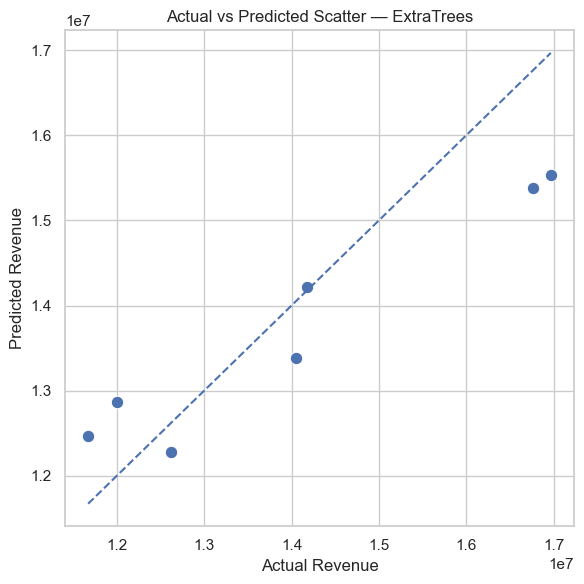

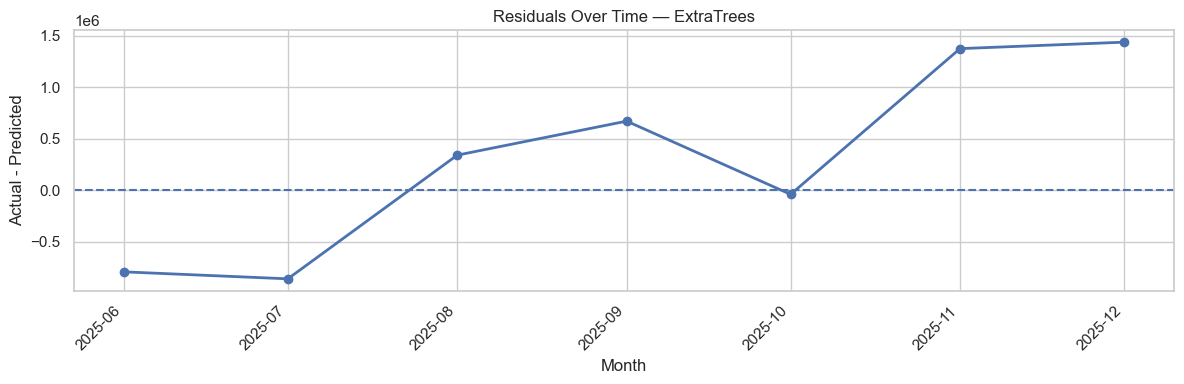

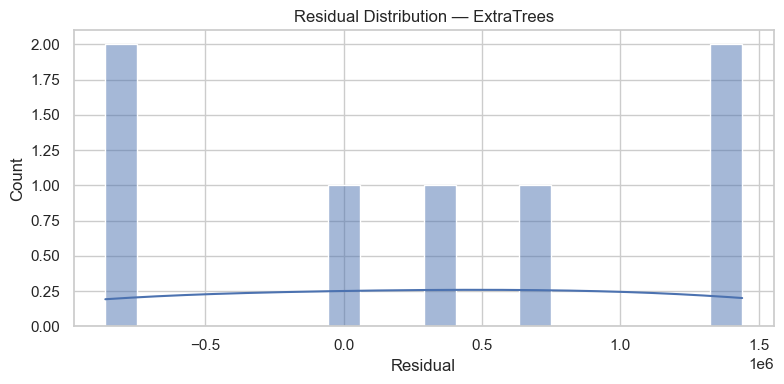

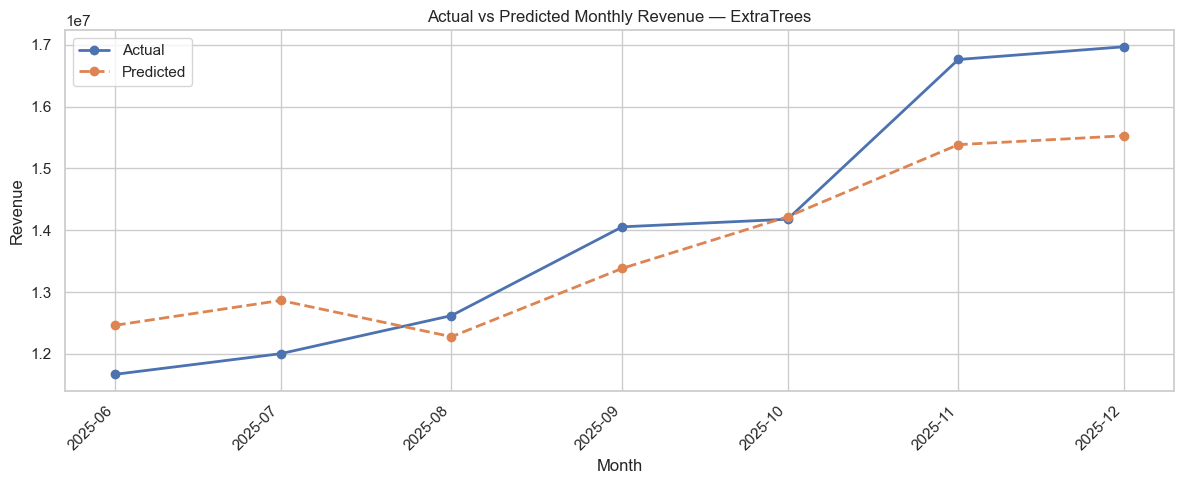

,month,target_eur,predicted_eur,residual
29,2025-06-01,"11,671,141.190","12,464,508.393","-793,367.203"
30,2025-07-01,"12,004,633.880","12,865,817.151","-861,183.271"
31,2025-08-01,"12,620,414.480","12,278,893.814","341,520.666"
32,2025-09-01,"14,056,380.450","13,384,206.441","672,174.009"
33,2025-10-01,"14,179,560.160","14,219,486.020","-39,925.860"
34,2025-11-01,"16,763,201.580","15,385,953.399","1,377,248.181"
35,2025-12-01,"16,968,787.350","15,528,794.266","1,439,993.084"


In [16]:
def format_millions(x, pos):
    return f"{x / 1_000_000:.1f}M"

def polish_axis(ax):
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FuncFormatter(format_millions))
    ax.tick_params(axis="x", rotation=45)

def plot_forecast_evaluation(test_df, y_pred_eur, model_name):
    """Create business-friendly evaluation plots."""
    eval_df = test_df[["month", "target_eur"]].copy()
    eval_df["predicted_eur"] = y_pred_eur
    eval_df["residual"] = eval_df["target_eur"] - eval_df["predicted_eur"]

    # Scatter
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=eval_df, x="target_eur", y="predicted_eur", s=80)
    low = min(eval_df["target_eur"].min(), eval_df["predicted_eur"].min())
    high = max(eval_df["target_eur"].max(), eval_df["predicted_eur"].max())
    plt.plot([low, high], [low, high], linestyle="--")
    plt.title(f"Actual vs Predicted Scatter — {model_name}")
    plt.xlabel("Actual Revenue")
    plt.ylabel("Predicted Revenue")
    plt.tight_layout()
    plt.show()

    # Residuals over time
    plt.figure(figsize=(12, 4))
    plt.plot(eval_df["month"], eval_df["residual"], marker="o", linewidth=2)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuals Over Time — {model_name}")
    plt.xlabel("Month")
    plt.ylabel("Actual - Predicted")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Residual distribution
    plt.figure(figsize=(8, 4))
    sns.histplot(eval_df["residual"], bins=20, kde=True)
    plt.title(f"Residual Distribution — {model_name}")
    plt.xlabel("Residual")
    plt.tight_layout()
    plt.show()

    # Actual vs predicted over time
    plt.figure(figsize=(12, 5))
    plt.plot(eval_df["month"], eval_df["target_eur"], marker="o", label="Actual", linewidth=2)
    plt.plot(eval_df["month"], eval_df["predicted_eur"], marker="o", linestyle="--", label="Predicted", linewidth=2)
    plt.title(f"Actual vs Predicted Monthly Revenue — {model_name}")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return eval_df


evaluation_detail_df = plot_forecast_evaluation(
    test_df,
    best_prediction["pred_eur"],
    best_model_name
)

display(evaluation_detail_df)


**Interpretation:** The selected model follows the overall direction of the held-out period reasonably well, but it does not capture every month equally. It slightly overestimates June and July, then underestimates the stronger rise in November and December. October is predicted very closely, which suggests the model can match normal seasonal movement, but it is more conservative around sharper revenue peaks. This is a useful result for planning: the model captures the broad seasonal pattern and improves over simple baselines, but the residuals show that peak months still carry more uncertainty. 

## Feature importance

For tree-based models, feature importance gives a high-level view of which signals contribute most to the monthly forecast.

,feature,importance
2,quarter,0.390
1,month_num,0.233
39,total_quantity_lag_1,0.029
21,unique_customers_lag_1,0.024
18,unique_transactions_lag_1,0.023
24,unique_items_lag_1,0.021
7,revenue_lag_2,0.020
15,order_lines_lag_1,0.020
19,unique_transactions_rolling_mean_3,0.019
28,return_rate_rolling_mean_3,0.017


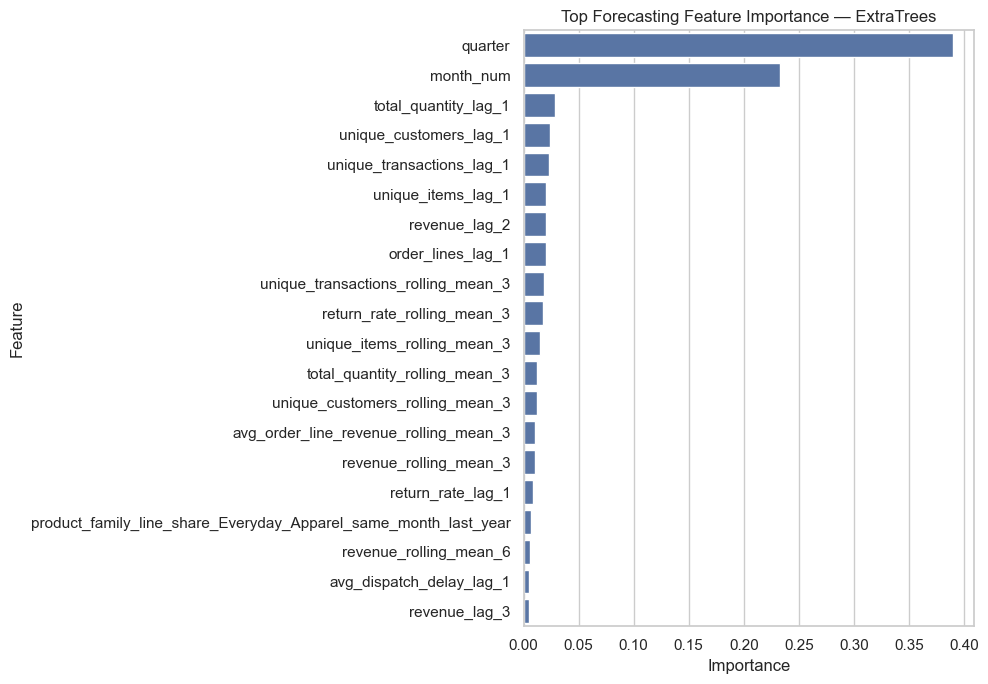

In [17]:
if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = None

if best_model is not None and hasattr(best_model.named_steps["model"], "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False).head(20)

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(f"Top Forecasting Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("The selected best model does not expose direct feature_importances_.")


**Interpretation:** The strongest feature-importance signals are seasonal variables such as quarter and month number, followed by recent volume and customer activity features. This matches the business logic of monthly revenue forecasting: seasonality sets much of the pattern, while recent order volume, customer activity, and revenue lags help adjust the forecast.

# 13. Forecast Future Months Dynamically

The notebook forecasts the next `FORECAST_HORIZON_MONTHS` months from the latest available month.

The process is recursive:

1. predict the next month
2. use that prediction as part of the lag history for the following month
3. repeat until the forecast horizon is complete

Unknown future business indicators are estimated from recent averages or same-month seasonal patterns where available.

In [18]:
def estimate_future_metric(history_df, metric_col, future_month):
    """Estimate an unknown future metric using same-month-last-year or recent average."""
    history = history_df.sort_values("month").copy()

    same_month_last_year = future_month - pd.DateOffset(years=1)
    same_month_row = history[history["month"] == same_month_last_year]

    if len(same_month_row) > 0 and metric_col in same_month_row.columns:
        value = same_month_row[metric_col].iloc[-1]
        if pd.notna(value):
            return value, "same_month_last_year"

    if metric_col in history.columns:
        recent_values = history[metric_col].dropna().tail(3)
        if len(recent_values) > 0:
            return recent_values.mean(), "recent_3_month_average"

        all_values = history[metric_col].dropna()
        if len(all_values) > 0:
            return all_values.median(), "historical_median"

    return np.nan, "missing"


def build_single_future_feature_row(history_df, future_month, feature_cols):
    """Create one future feature row using recursive revenue history."""
    row = {
        "month": future_month,
        "year": future_month.year,
        "month_num": future_month.month,
        "quarter": future_month.quarter,
        "month_index": history_df["month_index"].max() + 1,
        "is_year_start": int(future_month.month == 1),
        "is_year_end": int(future_month.month == 12),
    }

    # Revenue lags from actual/predicted history
    for lag in [1, 2, 3, 6, 12]:
        col = f"revenue_lag_{lag}"
        if col in feature_cols:
            row[col] = history_df["target_eur"].iloc[-lag] if len(history_df) >= lag else np.nan

    previous_revenue = history_df["target_eur"]
    row["revenue_rolling_mean_3"] = previous_revenue.tail(3).mean()
    row["revenue_rolling_mean_6"] = previous_revenue.tail(6).mean()
    row["revenue_rolling_std_3"] = previous_revenue.tail(3).std() if len(previous_revenue.tail(3)) >= 2 else 0
    row["revenue_rolling_std_6"] = previous_revenue.tail(6).std() if len(previous_revenue.tail(6)) >= 2 else 0

    assumption_notes = []

    base_business_cols = [
        "order_lines", "unique_transactions", "unique_customers", "unique_items",
        "return_rate", "avg_order_line_revenue", "avg_price", "avg_discount",
        "total_quantity", "avg_dispatch_delay", "avg_delivery_delay"
    ]
    base_business_cols += [
        c for c in history_df.columns
        if c.startswith("channel_") or c.startswith("product_family_")
    ]

    for base_col in base_business_cols:
        if f"{base_col}_lag_1" in feature_cols:
            value, method = estimate_future_metric(history_df, base_col, future_month)
            row[f"{base_col}_lag_1"] = value
            assumption_notes.append(f"{base_col}:{method}")

        if f"{base_col}_rolling_mean_3" in feature_cols:
            values = history_df[base_col].dropna().tail(3) if base_col in history_df.columns else pd.Series(dtype=float)
            row[f"{base_col}_rolling_mean_3"] = values.mean() if len(values) > 0 else np.nan

        if f"{base_col}_same_month_last_year" in feature_cols:
            value, _ = estimate_future_metric(history_df, base_col, future_month)
            row[f"{base_col}_same_month_last_year"] = value

    feature_row = pd.DataFrame([{col: row.get(col, np.nan) for col in feature_cols}])
    notes = "; ".join(assumption_notes[:8])

    return feature_row, row, notes


def forecast_future_months(best_model, monthly_history, feature_cols, horizon_months, residual_std_eur):
    """Recursively forecast future monthly realized revenue."""
    history = monthly_history.copy().sort_values("month").reset_index(drop=True)
    forecast_rows = []

    latest_month = history["month"].max()

    for step in range(1, horizon_months + 1):
        future_month = latest_month + pd.DateOffset(months=step)

        X_future, row_data, notes = build_single_future_feature_row(history, future_month, feature_cols)

        pred_log = best_model.predict(X_future)[0]
        pred_eur = max(0, np.expm1(pred_log))

        lower = max(0, pred_eur - 1.96 * residual_std_eur)
        upper = pred_eur + 1.96 * residual_std_eur

        forecast_rows.append({
            "forecast_month": future_month,
            "predicted_revenue_log": pred_log,
            "predicted_revenue_eur": pred_eur,
            "lower_reasonable_estimate": lower,
            "upper_reasonable_estimate": upper,
            "notes_assumptions": notes
        })

        # Add predicted month into history for recursive lag creation.
        new_history_row = {col: np.nan for col in history.columns}
        new_history_row.update(row_data)
        new_history_row["month"] = future_month
        new_history_row["target_eur"] = pred_eur
        new_history_row["target_log"] = np.log1p(pred_eur)
        new_history_row["total_realized_revenue"] = pred_eur

        raw_cols = [
            "order_lines", "unique_transactions", "unique_customers", "unique_items",
            "return_rate", "avg_order_line_revenue", "avg_price", "avg_discount",
            "total_quantity", "avg_dispatch_delay", "avg_delivery_delay"
        ]
        raw_cols += [
            c for c in history.columns
            if c.startswith("channel_") or c.startswith("product_family_")
        ]

        for col in raw_cols:
            if col in history.columns:
                value, _ = estimate_future_metric(history, col, future_month)
                new_history_row[col] = value

        history = pd.concat([history, pd.DataFrame([new_history_row])], ignore_index=True)

    return pd.DataFrame(forecast_rows)


# If a baseline wins, use the best ML model for recursive forecasting.
if best_model_name in models:
    forecasting_model = models[best_model_name]
    forecasting_model_name = best_model_name
else:
    ml_rows = model_comparison[model_comparison["model"].isin(models.keys())]
    forecasting_model_name = ml_rows.iloc[0]["model"]
    forecasting_model = models[forecasting_model_name]
    print(f"Best overall model was a baseline. Using best ML model for recursive forecasting: {forecasting_model_name}")

best_residuals = y_test_eur.values - best_prediction["pred_eur"]
residual_std_eur = np.nanstd(best_residuals)

future_forecast_df = forecast_future_months(
    best_model=forecasting_model,
    monthly_history=feature_df,
    feature_cols=feature_cols,
    horizon_months=FORECAST_HORIZON_MONTHS,
    residual_std_eur=residual_std_eur
)



Forecast visualization combines:

- historical actual revenue
- forecasted future revenue
- an approximate planning range

The range is based on historical test residual error.

,forecast_month,predicted_revenue_log,predicted_revenue_eur,lower_reasonable_estimate,upper_reasonable_estimate,notes_assumptions
0,2026-01-01,16.160,"10,429,012.503","8,730,076.786","12,127,948.219",order_lines:same_month_last_year; unique_trans...
1,2026-02-01,16.164,"10,470,731.363","8,771,795.647","12,169,667.080",order_lines:same_month_last_year; unique_trans...
2,2026-03-01,16.190,"10,747,253.646","9,048,317.930","12,446,189.363",order_lines:same_month_last_year; unique_trans...
3,2026-04-01,16.345,"12,545,921.697","10,846,985.981","14,244,857.414",order_lines:same_month_last_year; unique_trans...
4,2026-05-01,16.350,"12,613,671.601","10,914,735.885","14,312,607.317",order_lines:same_month_last_year; unique_trans...
5,2026-06-01,16.338,"12,463,859.726","10,764,924.010","14,162,795.442",order_lines:same_month_last_year; unique_trans...
6,2026-07-01,16.318,"12,212,778.032","10,513,842.315","13,911,713.748",order_lines:same_month_last_year; unique_trans...
7,2026-08-01,16.387,"13,080,479.251","11,381,543.535","14,779,414.968",order_lines:same_month_last_year; unique_trans...


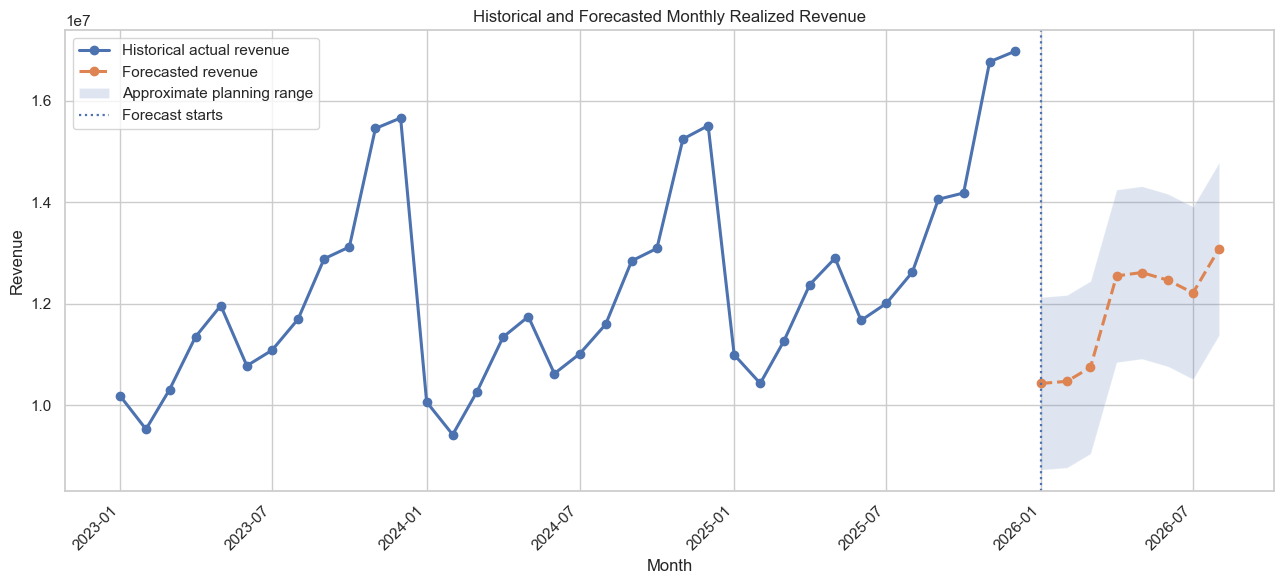

In [19]:
display(future_forecast_df)


plt.figure(figsize=(13, 6))

plt.plot(
    monthly_df["month"],
    monthly_df["total_realized_revenue"],
    marker="o",
    linewidth=2.2,
    label="Historical actual revenue"
)

plt.plot(
    future_forecast_df["forecast_month"],
    future_forecast_df["predicted_revenue_eur"],
    marker="o",
    linestyle="--",
    linewidth=2.2,
    label="Forecasted revenue"
)

plt.fill_between(
    future_forecast_df["forecast_month"],
    future_forecast_df["lower_reasonable_estimate"],
    future_forecast_df["upper_reasonable_estimate"],
    alpha=0.18,
    label="Approximate planning range"
)

forecast_start = future_forecast_df["forecast_month"].min()
plt.axvline(forecast_start, linestyle=":", linewidth=1.6, label="Forecast starts")

plt.title("Historical and Forecasted Monthly Realized Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**  
The forecast continues the seasonal pattern seen in the historical data. After the strong year-end peak in 2025, the model expects revenue to reset to a lower level in early 2026, which is consistent with the previous January drops in the historical series. From April onward, the forecast moves back into a stronger range, with August showing the highest forecasted month in this horizon. The shaded area shows the level of uncertainty around the monthly estimates. 

## Yearly actual and forecast together

source,year,actual,forecast,total_actual_plus_forecast
0,2023,"143,998,222.510",0.000,"143,998,222.510"
1,2024,"142,747,822.010",0.000,"142,747,822.010"
2,2025,"156,221,321.550",0.000,"156,221,321.550"
3,2026,0.000,"94,563,707.820","94,563,707.820"


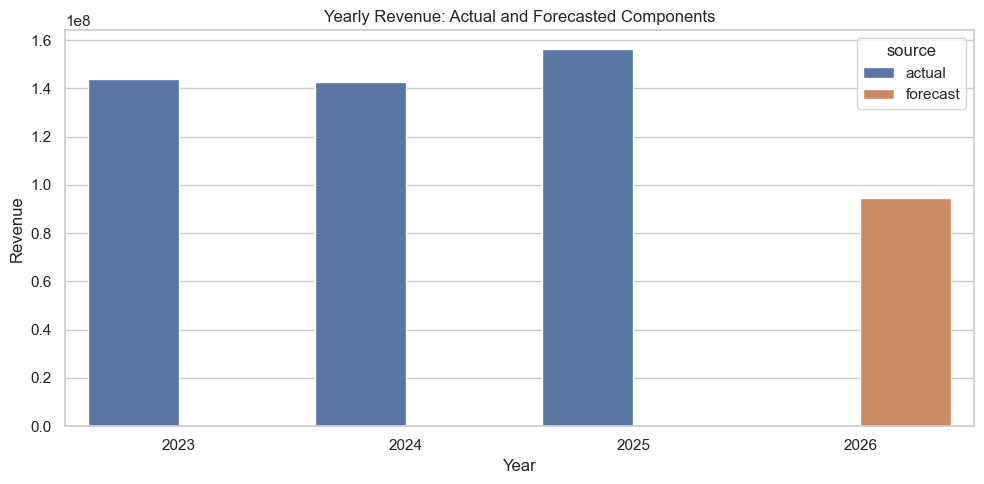

In [20]:
def build_yearly_actual_forecast_summary(monthly_actuals, future_forecast):
    """Combine historical actuals and future forecasts into yearly summary."""
    actual = monthly_actuals[["month", "total_realized_revenue"]].copy()
    actual = actual.rename(columns={"total_realized_revenue": "revenue"})
    actual["source"] = "actual"

    forecast = future_forecast[["forecast_month", "predicted_revenue_eur"]].copy()
    forecast = forecast.rename(columns={"forecast_month": "month", "predicted_revenue_eur": "revenue"})
    forecast["source"] = "forecast"

    combined = pd.concat([actual, forecast], ignore_index=True)
    combined["year"] = combined["month"].dt.year

    yearly_summary = (
        combined.groupby(["year", "source"])["revenue"]
        .sum()
        .unstack(fill_value=0)
        .reset_index()
    )

    yearly_summary["total_actual_plus_forecast"] = (
    yearly_summary.get("actual", 0) + yearly_summary.get("forecast", 0)
    )

    return combined, yearly_summary


actual_forecast_monthly_df, yearly_revenue_summary = build_yearly_actual_forecast_summary(
    monthly_df,
    future_forecast_df
)

display(yearly_revenue_summary)

plt.figure(figsize=(10, 5))
yearly_plot = yearly_revenue_summary.melt(
    id_vars="year",
    value_vars=[c for c in ["actual", "forecast"] if c in yearly_revenue_summary.columns],
    var_name="source",
    value_name="revenue"
)

sns.barplot(data=yearly_plot, x="year", y="revenue", hue="source")
plt.title("Yearly Revenue: Actual and Forecasted Components")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


Here we can see forecasted revenue next to completed historical years. In this output, 2026 contains the forecasted months only (8 months). 

# 14. Forecast Business Summary

The goal is to turn the month-by-month forecast into a compact planning view.

It highlights:

- latest actual month
- first forecast month
- expected revenue over the forecast horizon
- average forecasted monthly revenue
- strongest and weakest forecasted months
- comparison with the latest actual month

In [21]:
def build_forecast_business_summary(monthly_actuals, future_forecast, yearly_summary=None):
    """Create a compact business-facing summary from forecast results."""
    actuals = monthly_actuals.sort_values("month").copy()
    forecast = future_forecast.sort_values("forecast_month").copy()

    latest_actual_month = actuals["month"].max()
    latest_actual_revenue = actuals.loc[
        actuals["month"] == latest_actual_month,
        "total_realized_revenue"
    ].iloc[0]

    first_forecast_month = forecast["forecast_month"].min()
    first_forecast_revenue = forecast.loc[
        forecast["forecast_month"] == first_forecast_month,
        "predicted_revenue_eur"
    ].iloc[0]

    total_forecasted_revenue = forecast["predicted_revenue_eur"].sum()
    avg_forecasted_monthly_revenue = forecast["predicted_revenue_eur"].mean()

    highest_row = forecast.loc[forecast["predicted_revenue_eur"].idxmax()]
    lowest_row = forecast.loc[forecast["predicted_revenue_eur"].idxmin()]

    change_vs_latest_actual = first_forecast_revenue - latest_actual_revenue
    pct_change_vs_latest_actual = (
        change_vs_latest_actual / latest_actual_revenue
        if latest_actual_revenue != 0
        else np.nan
    )

    rows = [
        ("Latest actual month", latest_actual_month.strftime("%Y-%m")),
        ("Latest actual monthly revenue", latest_actual_revenue),
        ("First forecast month", first_forecast_month.strftime("%Y-%m")),
        ("First forecast month predicted revenue", first_forecast_revenue),
        ("Change vs latest actual month", change_vs_latest_actual),
        ("Percent change vs latest actual month", pct_change_vs_latest_actual),
        ("Total forecasted revenue over horizon", total_forecasted_revenue),
        ("Average forecasted monthly revenue", avg_forecasted_monthly_revenue),
        ("Highest forecasted month", highest_row["forecast_month"].strftime("%Y-%m")),
        ("Highest forecasted revenue", highest_row["predicted_revenue_eur"]),
        ("Lowest forecasted month", lowest_row["forecast_month"].strftime("%Y-%m")),
        ("Lowest forecasted revenue", lowest_row["predicted_revenue_eur"]),
    ]

    if yearly_summary is not None and len(yearly_summary) > 0:
        for year in forecast["forecast_month"].dt.year.unique():
            year_row = yearly_summary[yearly_summary["year"] == year]
            if len(year_row) > 0 and "total_actual_plus_forecast" in year_row.columns:
                rows.append((f"Actual + forecast revenue for {year}", year_row["total_actual_plus_forecast"].iloc[0]))

    summary = pd.DataFrame(rows, columns=["metric", "value"])

    formatted = []
    for metric, value in rows:
        if isinstance(value, str):
            formatted.append(value)
        elif "Percent" in metric:
            formatted.append(f"{value:.2%}" if pd.notna(value) else "n/a")
        else:
            formatted.append(f"{value:,.2f}" if pd.notna(value) else "n/a")

    summary["display_value"] = formatted
    return summary


forecast_business_summary = build_forecast_business_summary(
    monthly_df,
    future_forecast_df,
    yearly_revenue_summary
)

display(forecast_business_summary[["metric", "display_value"]])


,metric,display_value
0,Latest actual month,2025-12
1,Latest actual monthly revenue,"16,968,787.35"
2,First forecast month,2026-01
3,First forecast month predicted revenue,"10,429,012.50"
4,Change vs latest actual month,"-6,539,774.85"
5,Percent change vs latest actual month,-38.54%
6,Total forecasted revenue over horizon,"94,563,707.82"
7,Average forecasted monthly revenue,"11,820,463.48"
8,Highest forecasted month,2026-08
9,Highest forecasted revenue,"13,080,479.25"


**Interpretation:** In this run, the first forecasted month is below the latest actual month, which is expected when moving from a strong December into January. Across the forecast horizon, the model estimates roughly €94.6M in total revenue, with an average monthly forecast of about €11.8M. August is the strongest forecasted month and January is the weakest. 

## Forecasted Monthly Revenue

The chart below focuses only on the forecast horizon. This view is often easier to discuss with a business audience than the full historical line chart because it highlights the expected month-by-month planning pattern.

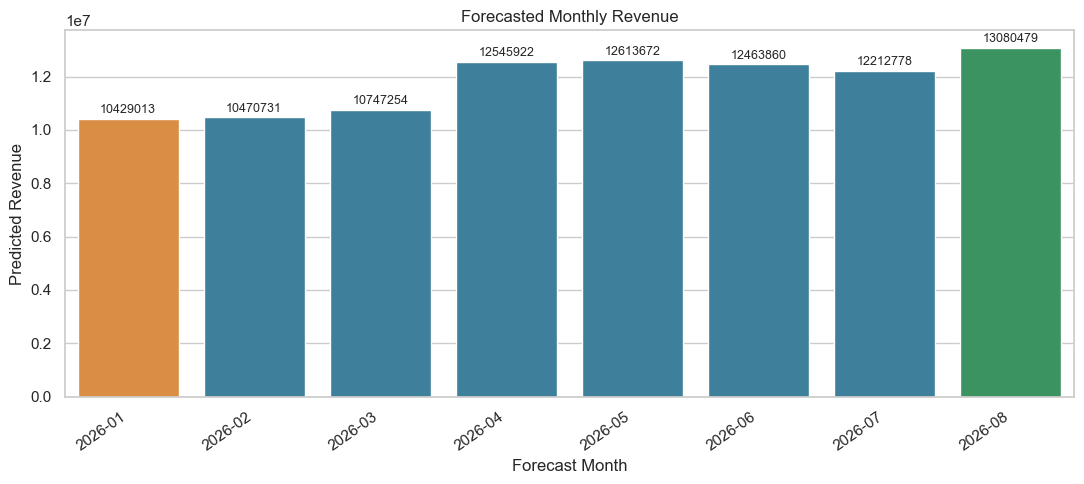

Strongest forecasted month: 2026-08
Weakest forecasted month: 2026-01


In [22]:
plt.figure(figsize=(11, 5))

bar_data = future_forecast_df.copy()
bar_data["forecast_month_label"] = bar_data["forecast_month"].dt.strftime("%Y-%m")

max_idx = bar_data["predicted_revenue_eur"].idxmax()
min_idx = bar_data["predicted_revenue_eur"].idxmin()
colors = [
    "#2E86AB" if idx not in [max_idx, min_idx] else ("#2CA25F" if idx == max_idx else "#F28E2B")
    for idx in bar_data.index
]

ax = sns.barplot(
    data=bar_data,
    x="forecast_month_label",
    y="predicted_revenue_eur",
    palette=colors
)

plt.title("Forecasted Monthly Revenue")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Revenue")
plt.xticks(rotation=35, ha="right")

# Add value labels when readable
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", fontsize=9, padding=2)

plt.tight_layout()
plt.show()

strongest_month = bar_data.loc[max_idx, "forecast_month_label"]
weakest_month = bar_data.loc[min_idx, "forecast_month_label"]

print(f"Strongest forecasted month: {strongest_month}")
print(f"Weakest forecasted month: {weakest_month}")


**Interpretation:** The bar chart shows a lower start in January and stronger forecasted revenue later in the horizon. This view can support planning around expected stronger and weaker months. 

# 15. Product-Family Forecast Allocation

The main model forecasts **total monthly realized revenue**. This section does not build a separate product-family forecasting model. It allocates the total forecast using recent product-family revenue shares.

The logic is:

1. calculate recent realized revenue by product family
2. calculate each family’s recent revenue share
3. apply those shares to each future monthly revenue forecast

This gives a practical planning view of where forecasted revenue may come from if the recent product mix stays similar.

In [23]:
def build_product_family_forecast_allocation(
    order_line_df,
    future_forecast,
    schema,
    recent_months=6,
    top_n=10
):
    """Allocate total forecasted revenue across product families using recent revenue shares."""
    family_col = schema["product_category"]
    date_col = schema["order_date"]
    revenue_col = schema["realized_revenue"]

    required_cols = {family_col, date_col, revenue_col}
    if not required_cols.issubset(order_line_df.columns):
        missing = required_cols - set(order_line_df.columns)
        print(f"Product-family allocation skipped. Missing columns: {missing}")
        return None, None, None

    data = order_line_df[[family_col, date_col, revenue_col]].copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.dropna(subset=[family_col, date_col, revenue_col]).copy()

    data["month"] = data[date_col].dt.to_period("M").dt.to_timestamp()
    latest_month = data["month"].max()
    recent_start = latest_month - pd.DateOffset(months=recent_months - 1)

    recent_data = data[data["month"] >= recent_start].copy()

    family_revenue = (
        recent_data.groupby(family_col)
        .agg(recent_realized_revenue=(revenue_col, "sum"))
        .sort_values("recent_realized_revenue", ascending=False)
        .reset_index()
    )

    top_families = family_revenue.head(top_n)[family_col].tolist()

    recent_data["product_family_grouped"] = np.where(
        recent_data[family_col].isin(top_families),
        recent_data[family_col],
        "Other"
    )

    family_share_table = (
        recent_data.groupby("product_family_grouped")
        .agg(recent_realized_revenue=(revenue_col, "sum"))
        .sort_values("recent_realized_revenue", ascending=False)
        .reset_index()
        .rename(columns={"product_family_grouped": "product_family"})
    )

    total_recent_revenue = family_share_table["recent_realized_revenue"].sum()
    family_share_table["product_family_share"] = np.where(
        total_recent_revenue > 0,
        family_share_table["recent_realized_revenue"] / total_recent_revenue,
        np.nan
    )

    allocation_rows = []
    for _, forecast_row in future_forecast.iterrows():
        for _, family_row in family_share_table.iterrows():
            allocation_rows.append({
                "forecast_month": forecast_row["forecast_month"],
                "product_family": family_row["product_family"],
                "product_family_share": family_row["product_family_share"],
                "allocated_forecast_revenue": (
                    forecast_row["predicted_revenue_eur"] *
                    family_row["product_family_share"]
                )
            })

    family_allocation = pd.DataFrame(allocation_rows)

    family_total_forecast = (
        family_allocation.groupby("product_family")
        .agg(total_allocated_forecast_revenue=("allocated_forecast_revenue", "sum"))
        .sort_values("total_allocated_forecast_revenue", ascending=False)
        .reset_index()
    )

    return family_share_table, family_allocation, family_total_forecast


product_family_share_table, product_family_allocation_df, product_family_total_forecast = build_product_family_forecast_allocation(
    order_line_df=analysis_df,
    future_forecast=future_forecast_df,
    schema=SCHEMA,
    recent_months=6,
    top_n=10
)

if product_family_share_table is not None:
    print("Recent product-family revenue share:")
    display(product_family_share_table)

    print("Future product-family allocation preview:")
    display(product_family_allocation_df.head(20))

    print("Total allocated forecast revenue by product family:")
    display(product_family_total_forecast)


Recent product-family revenue share:


,product_family,recent_realized_revenue,product_family_share
0,Home Comfort,"13,838,265.130",0.160
1,Everyday Apparel,"13,484,316.600",0.156
2,Outdoor Living,"11,375,445.690",0.131
3,Active Lifestyle,"10,350,051.070",0.120
4,Digital Accessories,"9,008,736.460",0.104
5,Kids Essentials,"7,725,305.800",0.089
6,Beauty & Care,"6,104,580.810",0.070
7,Seasonal Gifts,"5,819,564.090",0.067
8,Office & Study,"5,170,879.450",0.060
9,Pet Lifestyle,"3,715,832.800",0.043


Future product-family allocation preview:


,forecast_month,product_family,product_family_share,allocated_forecast_revenue
0,2026-01-01,Home Comfort,0.160,"1,666,641.379"
1,2026-01-01,Everyday Apparel,0.156,"1,624,012.822"
2,2026-01-01,Outdoor Living,0.131,"1,370,026.395"
3,2026-01-01,Active Lifestyle,0.120,"1,246,530.777"
4,2026-01-01,Digital Accessories,0.104,"1,084,986.652"
5,2026-01-01,Kids Essentials,0.089,"930,413.906"
6,2026-01-01,Beauty & Care,0.070,"735,218.388"
7,2026-01-01,Seasonal Gifts,0.067,"700,891.783"
8,2026-01-01,Office & Study,0.060,"622,766.046"
9,2026-01-01,Pet Lifestyle,0.043,"447,524.357"


Total allocated forecast revenue by product family:


,product_family,total_allocated_forecast_revenue
0,Home Comfort,"15,112,052.873"
1,Everyday Apparel,"14,725,524.009"
2,Outdoor Living,"12,422,535.275"
3,Active Lifestyle,"11,302,754.900"
4,Digital Accessories,"9,837,974.661"
5,Kids Essentials,"8,436,406.487"
6,Beauty & Care,"6,666,496.638"
7,Seasonal Gifts,"6,355,244.635"
8,Office & Study,"5,646,849.725"
9,Pet Lifestyle,"4,057,868.614"


**Interpretation:** The recent product-family mix is concentrated in a few leading families. Home Comfort and Everyday Apparel have the largest recent shares, followed by Outdoor Living and Active Lifestyle.

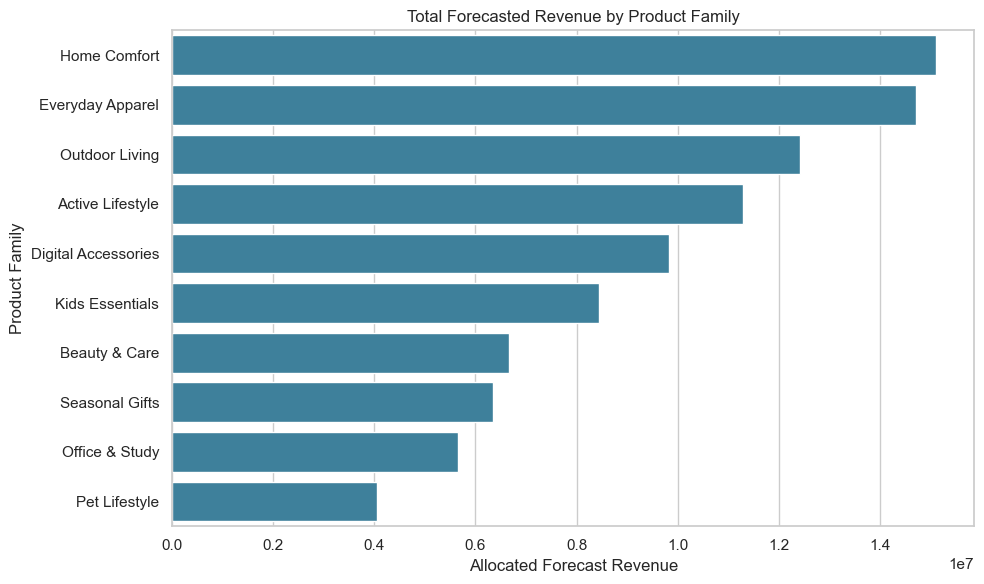

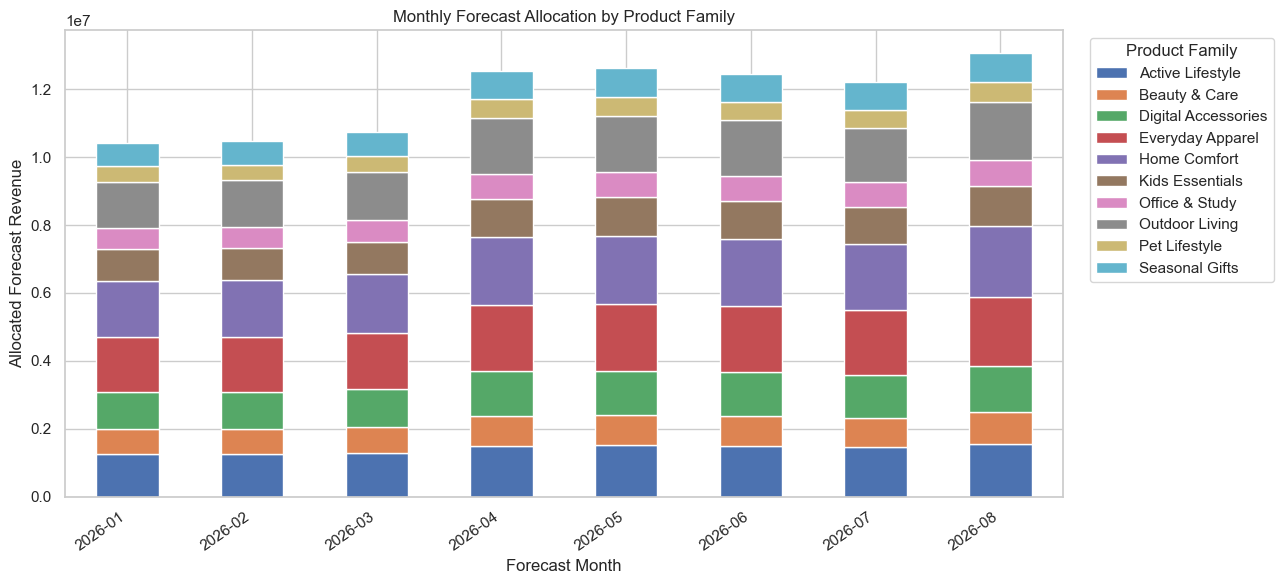

In [24]:
if product_family_total_forecast is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=product_family_total_forecast,
        x="total_allocated_forecast_revenue",
        y="product_family",
        color="#2E86AB"
    )
    plt.title("Total Forecasted Revenue by Product Family")
    plt.xlabel("Allocated Forecast Revenue")
    plt.ylabel("Product Family")
    plt.tight_layout()
    plt.show()

    monthly_family_pivot = (
        product_family_allocation_df
        .assign(forecast_month_label=lambda x: x["forecast_month"].dt.strftime("%Y-%m"))
        .pivot_table(
            index="forecast_month_label",
            columns="product_family",
            values="allocated_forecast_revenue",
            aggfunc="sum",
            fill_value=0
        )
    )

    monthly_family_pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(13, 6)
    )
    plt.title("Monthly Forecast Allocation by Product Family")
    plt.xlabel("Forecast Month")
    plt.ylabel("Allocated Forecast Revenue")
    plt.xticks(rotation=35, ha="right")
    plt.legend(title="Product Family", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Product-family forecast allocation was not created because the required product-family data was unavailable.")


**Interpretation:** The product-family charts show how the total forecast is distributed using the recent revenue mix. Home Comfort and Everyday Apparel receive the largest allocations because they hold the highest recent revenue shares.

# 16. Save Best Forecasting Model and Artifacts

This section saves the selected forecasting model and the main forecast outputs as local artifacts. These files are useful for rerunning the forecast or reviewing outputs later. Saved artifacts include:

- selected forecasting model
- feature columns
- monthly history needed for recursive forecasting
- model comparison table
- forecast results
- forecast business summary
- product-family allocation outputs

In [25]:
forecasting_metadata = {
    "model": forecasting_model,
    "model_name": forecasting_model_name,
    "feature_cols": feature_cols,
    "forecast_horizon_months": FORECAST_HORIZON_MONTHS,
    "residual_std_eur": residual_std_eur,
    "monthly_history": feature_df,
    "model_comparison": model_comparison,
    "target": "log1p(total monthly realized revenue)",
    "output_unit": "euros after expm1",
    "latest_available_month": monthly_df["month"].max(),
    "product_family_allocation_available": product_family_allocation_df is not None
}

model_path = MODEL_DIR / "best_revenue_forecasting_model.joblib"
metadata_path = MODEL_DIR / "revenue_forecasting_metadata.joblib"

joblib.dump(forecasting_model, model_path)
joblib.dump(forecasting_metadata, metadata_path)

future_forecast_path_parquet = OUTPUT_DIR / "revenue_forecast_results.parquet"
future_forecast_path_csv = OUTPUT_DIR / "revenue_forecast_results.csv"
yearly_summary_path = OUTPUT_DIR / "yearly_revenue_actual_forecast_summary.csv"
business_summary_path = OUTPUT_DIR / "revenue_forecast_business_summary.csv"

future_forecast_df.to_parquet(future_forecast_path_parquet, index=False)
future_forecast_df.to_csv(future_forecast_path_csv, index=False)
yearly_revenue_summary.to_csv(yearly_summary_path, index=False)
forecast_business_summary.to_csv(business_summary_path, index=False)

print("Saved artifacts:")
print("-", model_path.as_posix())
print("-", metadata_path.as_posix())
print("-", future_forecast_path_parquet.as_posix())
print("-", future_forecast_path_csv.as_posix())
print("-", yearly_summary_path.as_posix())
print("-", business_summary_path.as_posix())

if product_family_allocation_df is not None:
    family_share_path = OUTPUT_DIR / "revenue_forecast_product_family_shares.csv"
    family_allocation_path = OUTPUT_DIR / "revenue_forecast_product_family_allocation.parquet"
    family_allocation_csv_path = OUTPUT_DIR / "revenue_forecast_product_family_allocation.csv"
    family_total_path = OUTPUT_DIR / "revenue_forecast_product_family_totals.csv"

    product_family_share_table.to_csv(family_share_path, index=False)
    product_family_allocation_df.to_parquet(family_allocation_path, index=False)
    product_family_allocation_df.to_csv(family_allocation_csv_path, index=False)
    product_family_total_forecast.to_csv(family_total_path, index=False)

    print("-", family_share_path.as_posix())
    print("-", family_allocation_path.as_posix())
    print("-", family_allocation_csv_path.as_posix())
    print("-", family_total_path.as_posix())


Saved artifacts:
- models/best_revenue_forecasting_model.joblib
- models/revenue_forecasting_metadata.joblib
- outputs/revenue_forecast_results.parquet
- outputs/revenue_forecast_results.csv
- outputs/yearly_revenue_actual_forecast_summary.csv
- outputs/revenue_forecast_business_summary.csv
- outputs/revenue_forecast_product_family_shares.csv
- outputs/revenue_forecast_product_family_allocation.parquet
- outputs/revenue_forecast_product_family_allocation.csv
- outputs/revenue_forecast_product_family_totals.csv


# 17. Business Q&A and Ad-Hoc Analysis

This section demonstrates how the forecast outputs are used to answer real business questions.

---
## Q1: Which month in the forecast horizon should operations prepare hardest for?

The team wants to know where peak pressure is expected so planning can start early.

In [26]:
peak_row = future_forecast_df.loc[future_forecast_df["predicted_revenue_eur"].idxmax()]

operations_readout = pd.DataFrame([
    {
        "forecast_month": peak_row["forecast_month"].strftime("%Y-%m"),
        "point_forecast_eur": peak_row["predicted_revenue_eur"],
        "lower_planning_estimate": peak_row["lower_reasonable_estimate"],
        "upper_planning_estimate": peak_row["upper_reasonable_estimate"],
    }
])

display(
    operations_readout.style.format({
        "point_forecast_eur": "{:,.0f}",
        "lower_planning_estimate": "{:,.0f}",
        "upper_planning_estimate": "{:,.0f}",
    })
)


,forecast_month,point_forecast_eur,lower_planning_estimate,upper_planning_estimate
0,2026-08,"13,080,479","11,381,544","14,779,415"


**Answer:** August is the strongest forecasted month in the 8-month horizon. Operations planning should target the upper bound of the planning range as **€14,779,415**, not the point estimate, because under-capacity in a peak month is more costly than a small over-provision.

---
## Q2: The finance team is building the annual budget and needs a quarterly revenue line for Q1 2026 (January, February, March).



In [27]:
target_year = future_forecast_df["forecast_month"].dt.year.min()
target_quarter = 1

quarter_df = future_forecast_df[
    (future_forecast_df["forecast_month"].dt.year == target_year) &
    (future_forecast_df["forecast_month"].dt.quarter == target_quarter)
].copy()

if quarter_df.empty:
    quarter_df = future_forecast_df.sort_values("forecast_month").head(3).copy()
    quarter_label = "first three forecast months"
else:
    quarter_label = f"Q{target_quarter} {target_year}"

quarter_display = quarter_df[[
    "forecast_month",
    "predicted_revenue_eur",
    "lower_reasonable_estimate",
    "upper_reasonable_estimate",
]].copy()
quarter_display["forecast_month"] = quarter_display["forecast_month"].dt.strftime("%Y-%m")

quarter_summary = pd.DataFrame([
    {
        "planning_period": quarter_label,
        "point_forecast_eur": quarter_df["predicted_revenue_eur"].sum(),
        "lower_planning_estimate": quarter_df["lower_reasonable_estimate"].sum(),
        "upper_planning_estimate": quarter_df["upper_reasonable_estimate"].sum(),
        "downside_sensitivity": (
            quarter_df["predicted_revenue_eur"].sum() -
            quarter_df["lower_reasonable_estimate"].sum()
        ),
        "upside_sensitivity": (
            quarter_df["upper_reasonable_estimate"].sum() -
            quarter_df["predicted_revenue_eur"].sum()
        ),
    }
])

print(f"Monthly forecast detail for {quarter_label}:")
display(
    quarter_display.style.format({
        "predicted_revenue_eur": "{:,.0f}",
        "lower_reasonable_estimate": "{:,.0f}",
        "upper_reasonable_estimate": "{:,.0f}",
    })
)

print(f"Planning summary for {quarter_label}:")
display(
    quarter_summary.style.format({
        "point_forecast_eur": "{:,.0f}",
        "lower_planning_estimate": "{:,.0f}",
        "upper_planning_estimate": "{:,.0f}",
        "downside_sensitivity": "{:,.0f}",
        "upside_sensitivity": "{:,.0f}",
    })
)

Monthly forecast detail for Q1 2026:


,forecast_month,predicted_revenue_eur,lower_reasonable_estimate,upper_reasonable_estimate
0,2026-01,"10,429,013","8,730,077","12,127,948"
1,2026-02,"10,470,731","8,771,796","12,169,667"
2,2026-03,"10,747,254","9,048,318","12,446,189"


Planning summary for Q1 2026:


,planning_period,point_forecast_eur,lower_planning_estimate,upper_planning_estimate,downside_sensitivity,upside_sensitivity
0,Q1 2026,"31,646,998","26,550,190","36,743,805","5,096,807","5,096,807"


**Answer:** €31,646,998 is the budget line, alongside the lower and upper planning bounds of €5,096,807 as the sensitivity range. January alone accounts for the majority of the downside risk, as it is the hardest month to forecast accurately because it follows a strong December peak and the model's rolling lag features are still catching up.

---
## Q3: Which product families should marketing focus on for the next months?

The marketing team has a fixed budget and wants to allocate spend where the revenue potential is highest.

In [28]:
if product_family_total_forecast is not None and len(product_family_total_forecast) > 0:
    family_focus = product_family_total_forecast.copy()
    total_allocated_revenue = family_focus["total_allocated_forecast_revenue"].sum()
    family_focus["share_of_forecast_horizon"] = np.where(
        total_allocated_revenue > 0,
        family_focus["total_allocated_forecast_revenue"] / total_allocated_revenue,
        np.nan,
    )

    family_focus = family_focus.head(4).copy()

    display(
        family_focus.style.format({
            "total_allocated_forecast_revenue": "{:,.0f}",
            "share_of_forecast_horizon": "{:.1%}",
        })
    )
else:
    print("Product-family allocation is unavailable, so this ad-hoc check is skipped.")

,product_family,total_allocated_forecast_revenue,share_of_forecast_horizon
0,Home Comfort,"15,112,053",16.0%
1,Everyday Apparel,"14,725,524",15.6%
2,Outdoor Living,"12,422,535",13.1%
3,Active Lifestyle,"11,302,755",12.0%


**Answer:** Home Comfort and Everyday Apparel carry the largest forecasted revenue shares, making them the highest-value families to defend.

**Marketing investment logic:**  
- **Defend high-share families (Home Comfort, Everyday Apparel):** These drive the majority of revenue. Protecting conversion rate and reducing churn here has the largest absolute impact on the forecast.  
- **Grow mid-tier families (Outdoor Living, Active Lifestyle):** These show meaningful revenue share but have room to grow. Incremental spend here can shift the mix and reduce concentration risk.  